In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

TensorFlow version: 2.19.0
Keras version: 3.13.2


# **Why NOT NumPy**

In [ ]:
import numpy as np

# Simple function f(x) = x^2
def f(x):
    return x ** 2

# Gradient (derivative)
def gradient(x):
    return 2 * x

x = 5.0
learning_rate = 0.1

for i in range(10):
    x = x - learning_rate * gradient(x)

print("Final x:", x)
print("Final f(x):", f(x))


Final x: 0.5368709120000001
Final f(x): 0.2882303761517119


**Hard for big neural networks**

# **Automatic Gradient (TensorFlow way)**

In [ ]:
import tensorflow as tf

x = tf.Variable(5.0)

with tf.GradientTape() as tape:
    y = x ** 2

grad = tape.gradient(y, x)

print("Gradient:", grad.numpy())

Gradient: 10.0


TensorFlow does gradient automatically
This is why we use Keras

# **Fully Connected Layer**

In [ ]:
from tensorflow.keras.layers import Dense

layer = Dense(64, activation="sigmoid")

print(layer)

<Dense name=dense, built=False>


Dense = Fully Connected Layer

64 neurons

sigmoid activation

# **Load Data**

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


# **Normalize + Flatten**

In [ ]:
# Normalize (0 to 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten (28x28 → 784)
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

print("After reshape:", x_train.shape)

After reshape: (60000, 784)


# **One-hot Encoding**

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Label shape:", y_train.shape)


Label shape: (60000, 10)


# **Build Model**

In [ ]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(64, activation="sigmoid", input_shape=(784,)),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Model Summary**

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

# **Compile Model**

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# **Train Model**

In [ ]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6731 - loss: 1.0565 - val_accuracy: 0.8938 - val_loss: 0.3877
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9078 - loss: 0.3233 - val_accuracy: 0.9268 - val_loss: 0.2565
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9324 - loss: 0.2355 - val_accuracy: 0.9413 - val_loss: 0.2064
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9456 - loss: 0.1864 - val_accuracy: 0.9491 - val_loss: 0.1758
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9544 - loss: 0.1561 - val_accuracy: 0.9516 - val_loss: 0.1628
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9617 - loss: 0.1322 - val_accuracy: 0.9556 - val_loss: 0.1495
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9674 - loss: 0.1131 - val_accuracy: 0.9606 - val_loss: 0.1302
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9706 - loss: 0.1011 - val_accuracy: 0.

# **Evaluate Model**

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9665 - loss: 0.1129
Test Accuracy: 0.9664999842643738


# **Prediction**

In [ ]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

print("Predicted:", predicted_labels[0])
print("Actual:", np.argmax(y_test[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predicted: 7
Actual: 7


# **Save Model**

In [ ]:
model.save("model.h5")

# **Load Model**

In [ ]:
loaded_model = tf.keras.models.load_model("model.h5")

loaded_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9665 - loss: 0.1129


[0.11293408274650574, 0.9664999842643738]

# **Devnagari Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

train_dir = "/content/drive/MyDrive/AI/Data/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI/Data/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test"

print(os.listdir(train_dir))  # check folders

['digit_5', 'digit_9', 'digit_8', 'digit_4', 'digit_2', 'digit_7', 'digit_3', 'digit_6', 'digit_1', 'digit_0']


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

# **Function to Load Images**

In [ ]:
img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))  # digit_0, digit_1...
    class_map = {name: i for i, name in enumerate(class_names)}

    print("Class mapping:", class_map)

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            # Load image
            img = Image.open(img_path).convert("L")   # grayscale
            img = img.resize((img_width, img_height))  # resize
            img = np.array(img) / 255.0  # normalize

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# **Load Data**

In [ ]:
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Train shape: (16999, 28, 28)
Test shape: (3000, 28, 28)


# **Reshape for Keras**

In [ ]:
# Add channel dimension (VERY IMPORTANT)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("New shape:", x_train.shape)

New shape: (16999, 28, 28, 1)


# **One-Hot Encoding**

In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Label shape:", y_train.shape)

Label shape: (16999, 10)


# **Visualize Images**

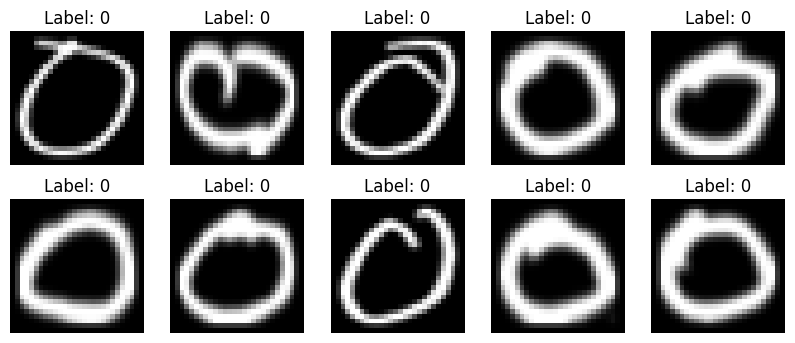

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Label: " + str(np.argmax(y_train[i])))
    plt.axis('off')

plt.show()

# **Build FCN Model**

In [ ]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28, 1)),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# **Train Model**

In [ ]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4550 - loss: 1.6196 - val_accuracy: 0.0000e+00 - val_loss: 8.3375
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8235 - loss: 0.5384 - val_accuracy: 0.0000e+00 - val_loss: 9.6009
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9167 - loss: 0.2847 - val_accuracy: 0.0000e+00 - val_loss: 10.1895
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9452 - loss: 0.1926 - val_accuracy: 0.0000e+00 - val_loss: 10.6694
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9557 - loss: 0.1494 - val_accuracy: 0.0000e+00 - val_loss: 10.9736
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9667 - loss: 0.1208 - val_accuracy: 0.0000e+00 - val_loss: 11.0776
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9712 - loss: 0.0998 - val_accuracy: 0.0000e+00 - val_loss: 11.3113
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9776 

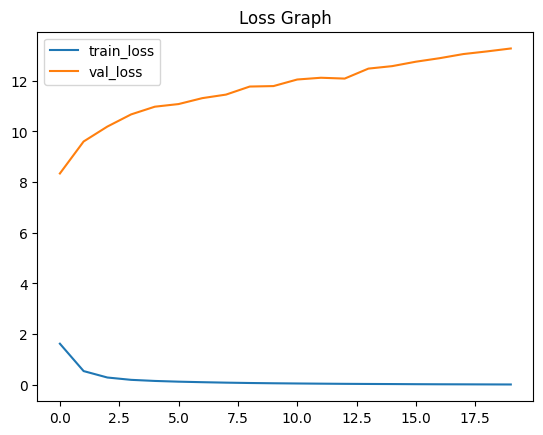

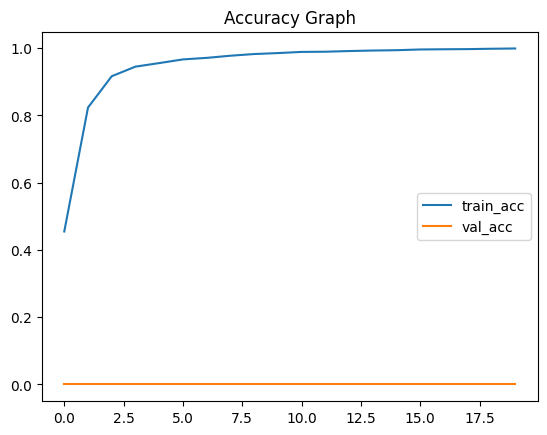

In [ ]:
# Loss graph
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

# Accuracy graph
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7837 - loss: 2.7165
Test Accuracy: 0.7836666703224182


In [ ]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

print("Predicted:", predicted_labels[0])
print("Actual:", np.argmax(y_test[0]))

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted: 0
Actual: 0


In [ ]:
model.save("devnagari_model.h5")

In [ ]:
loaded_model = tf.keras.models.load_model("devnagari_model.h5")

loaded_model.evaluate(x_test, y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7837 - loss: 2.7165


[2.716465711593628, 0.7836666703224182]